# Issue #1 — Chart 1: Apparel prices vs. real wages, 2000-present

**Question:** did apparel prices really diverge from wages during the fast fashion era?

**Ending sentence this chart supports:** "Fast fashion narrowed the price gap, but not the burden gap."

**Data sources (all from FRED):**
- `CPIAPPSL` — Apparel CPI
- `CES0500000003` — Average hourly earnings, all private employees (starts 2006)
- `AHETPI` — Average hourly earnings, production and nonsupervisory employees (goes back to 1964, used to extend pre-2006)
- `CPIAUCSL` — CPI all items (for inflation adjustment)

**Method:** splice the two wage series at their overlap, deflate to real wages using CPI, then index both apparel CPI and real wages to 100 in January 2000 for direct comparison.

**Honest caveat we'll disclose:** the pre-2006 wage series covers only production and nonsupervisory workers, which is a subset of the all-employees series used post-2006. The splice introduces a small methodological seam we'll validate at the overlap.

## 1. Setup

In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Paths — the notebook lives in notebooks/, so go up one level for repo root
REPO_ROOT = Path.cwd().parent.parent
RAW_DIR = REPO_ROOT / "data" / "raw" / "issue-01"
PROCESSED_DIR = REPO_ROOT / "data" / "processed" / "issue-01"
POST_EXPORTS = REPO_ROOT / "content" / "posts" / "issue-01-buy-now-owe-later" / "exports"
PALETTE_FILE = REPO_ROOT / "brand" / "palette.json"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
POST_EXPORTS.mkdir(parents=True, exist_ok=True)

print(f"Repo root: {REPO_ROOT}")
print(f"Raw data: {RAW_DIR}")

Repo root: c:\Users\juvin\OneDrive\Desktop\data-worn-thin
Raw data: c:\Users\juvin\OneDrive\Desktop\data-worn-thin\data\raw\issue-01


## 2.  Load brand palette

In [2]:
def load_palette():
    fallback = {
        "cocoa": "#664E44",
        "dusty": "#B08B7F",
        "peach": "#FFE8D6",
        "cream": "#FAF4E5",
        "sage": "#C7C3B0",
    }
    if not PALETTE_FILE.exists():
        return fallback
    try:
        with PALETTE_FILE.open() as f:
            data = json.load(f)
        if isinstance(data, dict):
            return {k.lower(): v for k, v in data.items()}
        return {item["name"].lower(): item["hex"] for item in data}
    except (json.JSONDecodeError, KeyError, TypeError):
        return fallback

PALETTE = load_palette()
PALETTE

{'cocoa': '#664E44',
 'dusty': '#B08B7F',
 'peach': '#FFE8D6',
 'cream': '#FAF4E5',
 'sage': '#C7C3B0'}

## 3. Inspect the raw file

In [9]:
FRED_FILES = {
    "apparel_cpi":       ("CPIAPPSL",       RAW_DIR / "CPIAPPSL.csv"),
    "wages_all":         ("CES0500000003",  RAW_DIR / "CES0500000003.csv"),
    "wages_prod_nonsup": ("AHETPI",         RAW_DIR / "AHETPI.csv"),
    "cpi_all":           ("CPIAUCSL",       RAW_DIR / "CPIAUCSL.csv"),
}

def load_fred(path: Path, series_code: str) -> pd.Series:
    # FRED CSVs have shifted between "DATE" and "observation_date" as the date col
    # over the years; this handles either case.
    df = pd.read_csv(path)
    date_col = "observation_date" if "observation_date" in df.columns else "DATE"
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.set_index(date_col)
    return df[series_code].astype(float).rename(series_code)

missing = [str(p) for _, p in FRED_FILES.values() if not p.exists()]
if missing:
    print("Missing files, download these before continuing:")
    for m in missing:
        print(f"  - {m}")
else:
    print("All four files found, loading...")

series = {name: load_fred(p, code) for name, (code, p) in FRED_FILES.items() if p.exists()}
for name, s in series.items():
    print(f"  {name}: {len(s)} rows, {s.index.min().date()} -> {s.index.max().date()}")

All four files found, loading...
  apparel_cpi: 954 rows, 1947-01-01 -> 2026-06-01
  wages_all: 244 rows, 2006-03-01 -> 2026-06-01
  wages_prod_nonsup: 750 rows, 1964-01-01 -> 2026-06-01
  cpi_all: 954 rows, 1947-01-01 -> 2026-06-01


## 4. Splice the two wage series

The all-employees series (`CES0500000003`) starts in March 2006. The production/nonsupervisory series (`AHETPI`) goes back to 1964. To extend the chart back to 2000, we use `AHETPI` for pre-2006 dates and `CES0500000003` from 2006 onward.

**Method choice:** we splice at the ratio of the two series at their overlap point (March 2006), so pre-2006 values are scaled to line up with the post-2006 series level. This preserves the *shape* of the pre-2006 series while making levels comparable.

**Caveat:** assumes production/nonsupervisory wages grew at a similar rate to all-employees wages pre-2006. Defensible but not perfect, worth naming in the caption or a methods note.

In [10]:
wages_all = series["wages_all"]
wages_pns = series["wages_prod_nonsup"]

# Find the overlap and compute the ratio at the first shared date
overlap_start = max(wages_all.index.min(), wages_pns.index.min())
ratio = wages_all.loc[overlap_start] / wages_pns.loc[overlap_start]
print(f"Splice point: {overlap_start.date()}")
print(f"All-employees value: {wages_all.loc[overlap_start]:.2f}")
print(f"Prod/nonsup value:   {wages_pns.loc[overlap_start]:.2f}")
print(f"Scaling ratio applied to pre-2006 series: {ratio:.4f}")

# Scale pre-2006 values, then concatenate
wages_pre = wages_pns[wages_pns.index < overlap_start] * ratio
wages_spliced = pd.concat([wages_pre, wages_all]).sort_index()
wages_spliced.name = "nominal_wages"

print(f"Spliced series: {len(wages_spliced)} rows, {wages_spliced.index.min().date()} -> {wages_spliced.index.max().date()}")

Splice point: 2006-03-01
All-employees value: 20.04
Prod/nonsup value:   16.54
Scaling ratio applied to pre-2006 series: 1.2116
Spliced series: 750 rows, 1964-01-01 -> 2026-06-01


### Sanity check the splice

The scaled pre-2006 series should sit smoothly next to the post-2006 series with no visible jump at the seam.

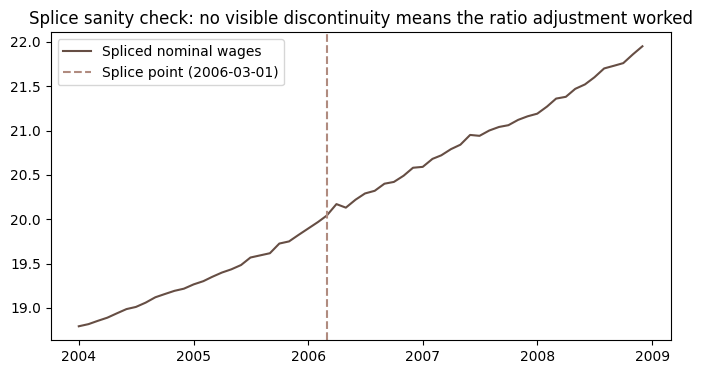

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
window = slice("2004-01-01", "2008-12-31")
ax.plot(wages_spliced.loc[window].index, wages_spliced.loc[window].values,
        color=PALETTE["cocoa"], label="Spliced nominal wages")
ax.axvline(overlap_start, color=PALETTE["dusty"], linestyle="--", label=f"Splice point ({overlap_start.date()})")
ax.set_title("Splice sanity check: no visible discontinuity means the ratio adjustment worked")
ax.legend()
plt.show()

## 5. Deflate nominal wages to real wages

Divide nominal wages by CPI-All-Items, then rescale to January 2000 dollars.

**Formula:** `real_wages = nominal_wages / cpi_all * cpi_all_2000_january`

In [12]:
cpi_all = series["cpi_all"]

# Align both series on the same monthly index
df = pd.concat([wages_spliced, cpi_all.rename("cpi_all")], axis=1).dropna()
df = df.loc["2000-01-01":]

# CPI value at January 2000 (the base)
cpi_base = df["cpi_all"].loc["2000-01-01"]
df["real_wages"] = df["nominal_wages"] / df["cpi_all"] * cpi_base

print(f"CPI at Jan 2000 (base): {cpi_base:.2f}")
print(df.head())
print("...")
print(df.tail())

CPI at Jan 2000 (base): 169.30
                  nominal_wages  cpi_all  real_wages
observation_date                                    
2000-01-01            16.647497    169.3   16.647497
2000-02-01            16.720193    170.0   16.651346
2000-03-01            16.780774    171.0   16.613947
2000-04-01            16.829238    170.9   16.671680
2000-05-01            16.877703    171.2   16.690392
...
                  nominal_wages  cpi_all  real_wages
observation_date                                    
2026-02-01                37.27  327.460   19.268952
2026-03-01                37.35  330.293   19.144684
2026-04-01                37.41  332.407   19.053489
2026-05-01                37.51  333.979   19.014498
2026-06-01                37.64  332.568   19.161350


## 6. Index both series to 100 in January 2000

In [13]:
apparel = series["apparel_cpi"]
apparel = apparel.loc["2000-01-01":]

apparel_indexed = apparel / apparel.loc["2000-01-01"] * 100
real_wages_indexed = df["real_wages"] / df["real_wages"].loc["2000-01-01"] * 100

chart_df = pd.concat([
    apparel_indexed.rename("apparel_index"),
    real_wages_indexed.rename("real_wages_index"),
], axis=1).dropna()

print(f"Chart data: {len(chart_df)} rows, {chart_df.index.min().date()} -> {chart_df.index.max().date()}")
print()
print("First and last values (both should start at 100.00):")
print(chart_df.head(1))
print(chart_df.tail(1))

Chart data: 317 rows, 2000-01-01 -> 2026-06-01

First and last values (both should start at 100.00):
                  apparel_index  real_wages_index
observation_date                                 
2000-01-01                100.0             100.0
                  apparel_index  real_wages_index
observation_date                                 
2026-06-01           104.294568        115.100489


Take a moment with the last row above:
- If **apparel_index** is well below 100: apparel got cheaper in absolute terms since 2000.
- If **apparel_index** is above 100 but well below real_wages_index: apparel got relatively cheaper, wages grew faster than clothing prices.
- If both are close: the gap didn't widen at the average level, the burden story lives at the distributional level (Chart 2), not average.

In [17]:
print("Apparel CPI (indexed):")
print(f"  Min: {chart_df['apparel_index'].min():.2f} on {chart_df['apparel_index'].idxmin().date()}")
print(f"  Max: {chart_df['apparel_index'].max():.2f} on {chart_df['apparel_index'].idxmax().date()}")

print("Real wages (indexed):")
print(f"  Min: {chart_df['real_wages_index'].min():.2f} on {chart_df['real_wages_index'].idxmin().date()}")
print(f"  Max: {chart_df['real_wages_index'].max():.2f} on {chart_df['real_wages_index'].idxmax().date()}")

Apparel CPI (indexed):
  Min: 87.41 on 2020-05-01
  Max: 104.87 on 2026-05-01
Real wages (indexed):
  Min: 99.80 on 2000-03-01
  Max: 119.32 on 2020-04-01


## 7. Chart

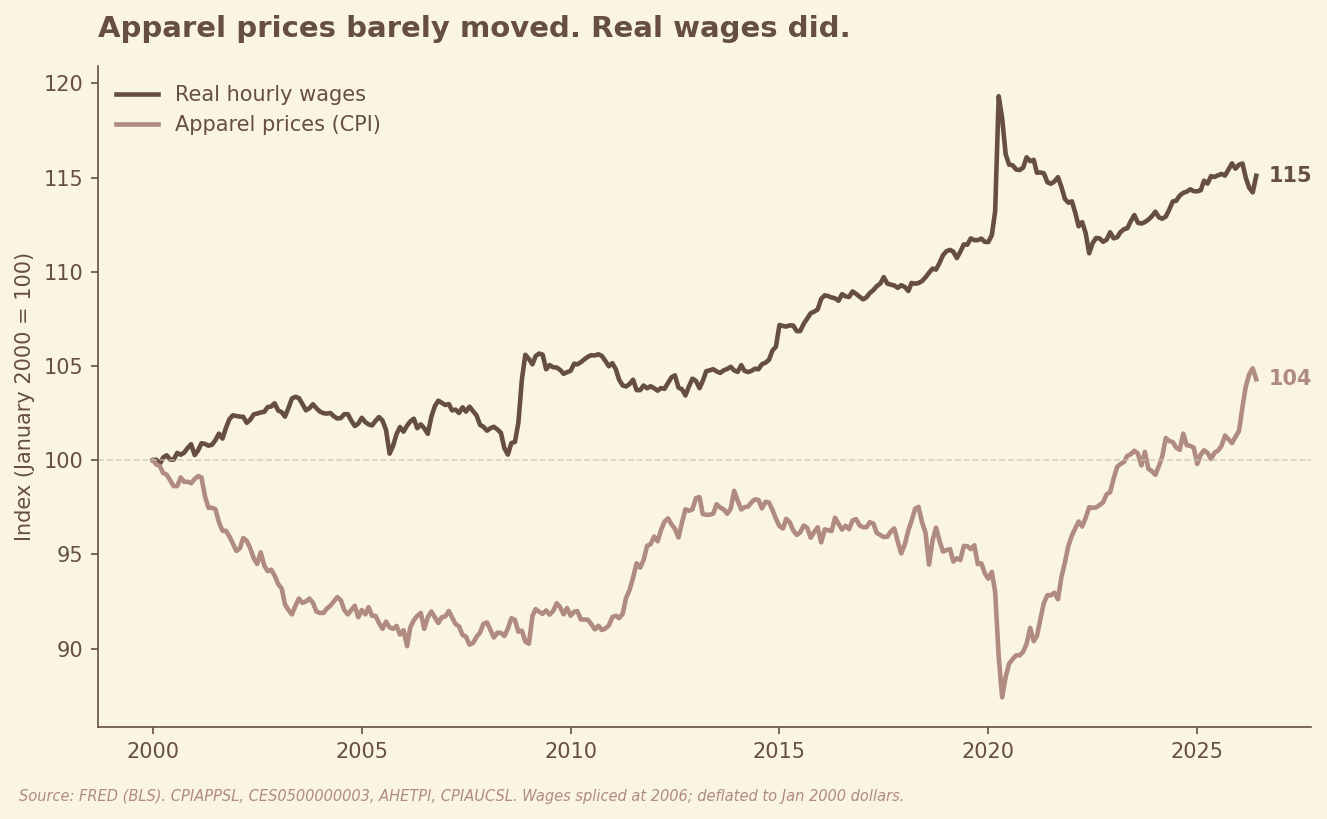

In [16]:
fig, ax = plt.subplots(figsize=(9, 5.5), dpi=150)
fig.patch.set_facecolor(PALETTE["cream"])
ax.set_facecolor(PALETTE["cream"])

ax.plot(chart_df.index, chart_df["real_wages_index"],
        color=PALETTE["cocoa"], linewidth=2.2, label="Real hourly wages")
ax.plot(chart_df.index, chart_df["apparel_index"],
        color=PALETTE["dusty"], linewidth=2.2, label="Apparel prices (CPI)")

# Reference line at 100
ax.axhline(100, color=PALETTE["sage"], linewidth=0.8, linestyle="--", alpha=0.7)

# End-of-series annotations
last_date = chart_df.index[-1]
ax.annotate(
    f"{chart_df['real_wages_index'].iloc[-1]:.0f}",
    xy=(last_date, chart_df["real_wages_index"].iloc[-1]),
    xytext=(6, 0), textcoords="offset points",
    color=PALETTE["cocoa"], fontsize=10, fontweight="bold", va="center",
)
ax.annotate(
    f"{chart_df['apparel_index'].iloc[-1]:.0f}",
    xy=(last_date, chart_df["apparel_index"].iloc[-1]),
    xytext=(6, 0), textcoords="offset points",
    color=PALETTE["dusty"], fontsize=10, fontweight="bold", va="center",
)

ax.set_title(
    "Apparel prices barely moved. Real wages did.",
    color=PALETTE["cocoa"], loc="left", pad=14,
    fontsize=14, fontweight="bold",
)
ax.set_ylabel("Index (January 2000 = 100)", color=PALETTE["cocoa"])

ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):
    ax.spines[spine].set_color(PALETTE["cocoa"])
ax.tick_params(colors=PALETTE["cocoa"])

ax.legend(loc="upper left", frameon=False, labelcolor=PALETTE["cocoa"])

fig.text(
    0.02, 0.02,
    "Source: FRED (BLS). CPIAPPSL, CES0500000003, AHETPI, CPIAUCSL. Wages spliced at 2006; deflated to Jan 2000 dollars.",
    fontsize=7, color=PALETTE["dusty"], style="italic",
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

## 8. Findings

For 20 years, clothes actually got cheaper. Fast fashion delivered on its promise. The chart above shows apparel prices (dusty line) trending downward from 2000 to about 2011, bottoming at roughly 87 on the January 2000 = 100 scale. That means, in real terms, apparel in the early 2010s cost about 13% less than it did at the start of the millennium.

But that era ended around 2020. The apparel line reverses sharply after 2020, and by mid-2026 it sits at 104, the highest point in the entire 26-year series. Apparel prices, in real terms, are now more expensive than they were in 2000.

Real wages (cocoa line) tell a calmer story: gradual growth from 100 in 2000 to about 115 by 2026, with an artificial spike during 2020 driven by pandemic-era layoffs of lower-wage workers (a compositional effect, not a real raise). Since 2020, wages have been essentially flat, right when apparel prices started climbing again.

Key numbers  
* Apparel CPI (real): 100 in Jan 2000 → 87 in May 2020 (low) → 104 in May 2026 (high)
* Real hourly wages (indexed): 100 in Jan 2000 → 115 in June 2026
* The gap between apparel and wages was widest in 2018-2019 (~25 points); it has narrowed to ~11 points by 2026, and is closing fast

## 9. Save Outputs

In [18]:
out_csv = PROCESSED_DIR / "apparel_vs_real_wages_indexed.csv"
chart_df.to_csv(out_csv)
print(f"Processed data saved to: {out_csv}")

out_png = POST_EXPORTS / "chart1_apparel_vs_wages.png"
fig.savefig(out_png, facecolor=fig.get_facecolor(), bbox_inches="tight")
print(f"Chart saved to: {out_png}")

Processed data saved to: c:\Users\juvin\OneDrive\Desktop\data-worn-thin\data\processed\issue-01\apparel_vs_real_wages_indexed.csv
Chart saved to: c:\Users\juvin\OneDrive\Desktop\data-worn-thin\content\posts\issue-01-buy-now-owe-later\exports\chart1_apparel_vs_wages.png


## 10. Sources cited in the analysis

In [21]:
# ---- 10. Sources cited in this analysis ---------------------------------
#
# Auto-generated from data/raw/issue-01/source-files/sources.csv
# so the notebook and any downstream captions cite exactly the same set.
# If a new source is added to sources.csv, re-run this cell to refresh the
# reference list 

SOURCES_FILE = REPO_ROOT / "data" / "raw" / "issue-01" / "source-files" / "sources.csv"

def format_apa(row):
    """Build an APA-7 style reference from a sources.csv row."""
    author = row["author_org"]
    year = row["year"]
    title = row["title"]
    url = row["url"]

    # Datasets and reports get italicized titles in APA
    if row["type"] in ("dataset", "report"):
        return f"{author}. ({year}). *{title}*. {url}"
    # Articles use plain title
    return f"{author}. ({year}). {title}. {url}"

if SOURCES_FILE.exists():
    sources = pd.read_csv(SOURCES_FILE)

    # Filter to only sources this notebook used, based on used_for column
    # Adjust the substring below to match this notebook's chart/section
    THIS_CHART = "Chart 1" 
    used_here = sources[sources["used_for"].str.contains(THIS_CHART, case=False, na=False)]

    print(f"Sources cited in {THIS_CHART}:")
    print("=" * 70)
    for _, row in used_here.iterrows():
        print(f"\n[{row['source_id']}] {format_apa(row)}")
        if pd.notna(row.get("notes")) and row["notes"]:
            print(f"    Notes: {row['notes']}")

    print()
    print("=" * 70)
    print(f"Full sources.csv: {SOURCES_FILE}")
    print(f"Total sources tracked: {len(sources)}, cited in {THIS_CHART}: {len(used_here)}")
else:
    print(f"Sources file not found at {SOURCES_FILE}")
    print("Create it before running this cell.")

Sources cited in Chart 1:

[FRED-1] U.S. Bureau of Labor Statistics via FRED. (2026). *Apparel CPI (CPIAPPSL)*. https://fred.stlouisfed.org/series/CPIAPPSL
    Notes: Monthly seasonally adjusted

[FRED-2] U.S. Bureau of Labor Statistics via FRED. (2026). *Average Hourly Earnings All Employees (CES0500000003)*. https://fred.stlouisfed.org/series/CES0500000003
    Notes: Starts March 2006

[FRED-3] U.S. Bureau of Labor Statistics via FRED. (2026). *Average Hourly Earnings Production Nonsupervisory (AHETPI)*. https://fred.stlouisfed.org/series/AHETPI
    Notes: Extends coverage back to 1964

[FRED-4] U.S. Bureau of Labor Statistics via FRED. (2026). *CPI All Items (CPIAUCSL)*. https://fred.stlouisfed.org/series/CPIAUCSL
    Notes: Used to convert wages to real terms

Full sources.csv: c:\Users\juvin\OneDrive\Desktop\data-worn-thin\data\raw\issue-01\source-files\sources.csv
Total sources tracked: 6, cited in Chart 1: 4
